In [14]:
# my scratch implementation
import numpy as np
import matplotlib.pyplot as plt
import copy
import math

In [3]:
x_train = np.array([[7.2, 12.8, 45.3, 22.1, 51.7, 9.4, 33.6, 18.9, 57.2, 28.4, 41.0, 14.6, 36.8, 24.3, 49.5, 11.1, 30.2, 55.9, 20.7, 43.8, 8.3, 26.5, 52.4, 16.2, 38.9, 47.1, 13.5, 34.7, 21.4, 58.6, 10.8, 44.2, 29.6, 17.3, 53.1, 25.8, 40.4, 12.0, 48.7, 31.9],[42.1, 8.5, 31.7, 55.2, 19.4, 47.8, 3.2, 38.6, 26.1, 12.9, 51.5, 34.0, 7.7, 44.3, 22.8, 58.1, 15.6, 40.9, 29.4, 5.1, 36.2, 49.7, 11.3, 53.8, 24.5, 17.0, 45.6, 32.3, 9.8, 41.4, 27.6, 20.2, 56.4, 13.7, 37.5, 2.4, 50.3, 30.8, 23.1, 46.9]])
y_train = np.array([24.1, 51.3, 194.4, 60.2, 235.0, 30.1, 155.5, 66.7, 231.9, 128.4, 137.2, 55.7, 170.3, 79.4, 213.4, 27.9, 133.6, 200.5, 74.7, 205.2, 29.3, 74.9, 244.7, 44.2, 165.4, 217.5, 44.5, 141.4, 96.5, 224.9, 40.7, 197.8, 91.7, 71.4, 214.2, 116.4, 156.9, 46.1, 209.7, 132.2])
x_train = x_train.T
print(f"x train: {x_train.shape}, y train: {y_train.shape}")

x train: (40, 2), y train: (40,)


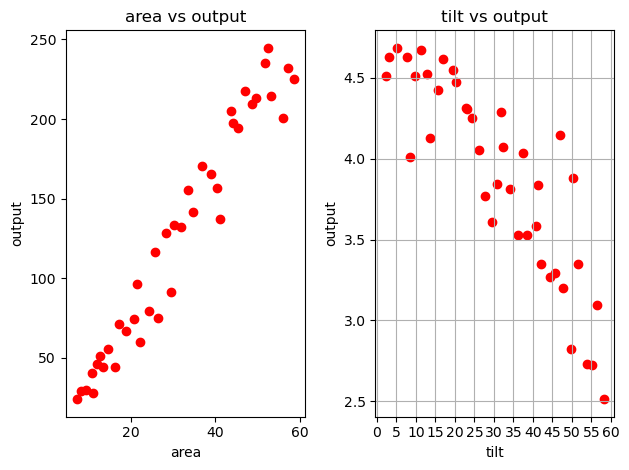

In [4]:
fig, ax = plt.subplots(1, 2)

ax[0].set_title("area vs output")
ax[0].set_xlabel("area")
ax[0].set_ylabel("output")
ax[0].scatter(x_train[:, 0], y_train, marker="o", color="r")

ax[1].set_title("tilt vs output")
ax[1].set_xlabel("tilt")
ax[1].grid(True)
ax[1].set_xticks(np.arange(0, 61, 5))
ax[1].set_ylabel("output")
ax[1].scatter(x_train[:, 1], y_train/x_train[:, 0], marker="o", color="r")

plt.tight_layout()
plt.show()

In [5]:
x_new_train = np.array([x_train[:, 0], x_train[:, 1], x_train[:, 0] * x_train[:, 1], x_train[:, 0] * (x_train[:, 1]**2)])
x_new_train = x_new_train.T
print(x_new_train.shape)
np.set_printoptions(suppress=True)

print(np.ptp(x_new_train, axis = 0))

(40, 4)
[    51.4       55.7     2364.12  108593.642]


In [6]:
def predict(x, w, b):
    prediction = x@w + b

    return prediction

In [7]:
def compute_cost(x, y, w, b):
    m = x.shape[0]
    
    cost = ((x@w + b) - y)**2
    cost = cost.sum()
    cost /= 2*m
    return cost


In [8]:
def compute_gradient(x, y, w, b):
    m = x.shape[0]
    n = w.shape[0]

    err = (x@w + b) - y
    dj_db = (err.sum())/ m
    dj_dw = err @ x

    dj_dw /= m

    return dj_dw, dj_db

w = np.array([0, 0, 0, 0])
b = 0
print(compute_gradient(x_new_train, y_train, w, b))

(array([   -5002.68425,    -3399.583  ,  -133308.24925, -4572105.50081]), np.float64(-125.8975))


In [9]:
def gradient_descent(x, y, w_init, b_init, iterations, alpha, threshold):
    j_history = []

    w = w_init
    b = b_init

    for i in range(iterations):
        dj_dw, dj_db  = compute_gradient(x, y, w, b)
        w = w - alpha*dj_dw
        b = b - alpha*dj_db


        j_history.append(compute_cost(x, y, w, b))

        if i % math.ceil(iterations / 10) == 0:
            print(f"Iteration: {i}, Cost: {j_history[-1]} --- [dj_dw: {dj_dw}, dj_db: {dj_db}]")

        if (np.all(abs(dj_dw) < threshold) and abs(dj_db) < threshold):
            print(f"Iteration: {i}, Cost: {j_history[-1]} --- [dj_dw: {dj_dw}, dj_db: {dj_db}]")
            break

    return j_history, w, b

In [10]:
def z_feature_scaling(x):
    mean = np.mean(x, axis = 0)
    sigma = np.std(x, axis = 0)

    x_scaled = (x - mean)/ sigma

    return x_scaled, mean, sigma

alpha: 0.3
Iteration: 0, Cost: 4845.296522219767 --- [dj_dw: [-69.23283491  27.97964858 -31.47698329 -11.03187612], dj_db: -125.8975]
Iteration: 63, Cost: 28.402383678262776 --- [dj_dw: [-0.4277054  -0.49797591  0.33940586  0.23366894], dj_db: -2.193782613346684e-08]


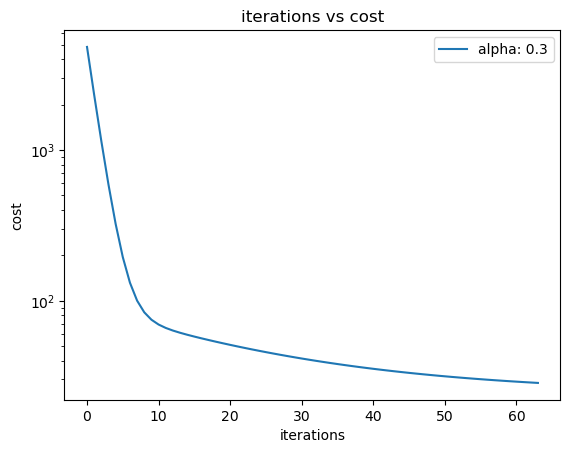

In [11]:
x_scaled, mean, sigma = z_feature_scaling(x_new_train)
alpha = np.array([0.3])
alpha_size = alpha.shape[0]
iterations = 1000
threshold = 0.5

w_init = np.zeros(4)
b_init = 0

cost_history = [0] * alpha_size

for i in range(alpha_size):
    print(f"alpha: {alpha[i]}")

    cost_history[i], w_final, b_final = gradient_descent(x_scaled, y_train, w_init, b_init, iterations, alpha[i], threshold)

plt.xlabel("iterations")
plt.ylabel("cost")
plt.title("iterations vs cost")
for i in range(alpha_size):
    label_1 = f"alpha: {alpha[i]}"
    plt.plot(cost_history[i], label=label_1)
    plt.yscale('log')

plt.legend()
plt.show()

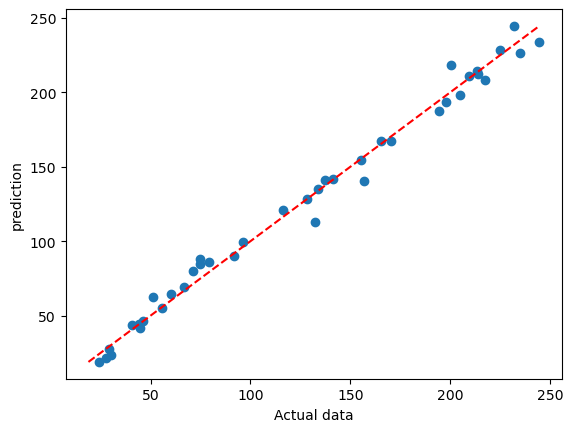

In [12]:
prediction = predict(x_scaled, w_final, b_final)
plt.scatter(y_train, prediction)
plt.xlabel("Actual data")
plt.ylabel("prediction")

lo = min(y_train.min(), prediction.min())
hi = max(y_train.max(), prediction.max())

plt.plot([lo, hi],[lo, hi], color='r', linestyle="--")
plt.show()

In [15]:
# my scratch implementation output
value_scaled = (np.array([35, 12, 35*12, 35*(12**2)]) - mean) / sigma
print("Predicted output:", predict(value_scaled, w_final, b_final))

Predicted output: 157.91966158598365
